In [7]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [6]:
from pandas import read_csv
import time
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif

In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

file_path = "/content/drive/MyDrive/ABQAA/salaries (8).csv"
df = pd.read_csv(file_path)

# Initialize LabelEncoder for categorical features and target
le_rank = LabelEncoder()
le_gender = LabelEncoder()

# Prepare features (X)
# Use 'rank', 'salary', 'service' as features
X_features = df[['rank', 'salary', 'service']].copy()

# Encode the 'rank' column numerically
X_features['rank'] = le_rank.fit_transform(X_features['rank'])
# Explicitly cast X to float type for GaussianNB
X = X_features.values.astype(float)

# Prepare target (y)
# Use 'gender' as the target variable and encode it numerically
y = le_gender.fit_transform(df['gender']) # Encodes 'Female'/'Male' to 0/1

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [21]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
import pandas as pd

# prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# create model
model_NB = GaussianNB()
# evaluate model
scores1 = cross_val_score(model_NB, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_NB, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_NB, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_NB, X_train, y_train, scoring='f1_macro', cv=cv)


In [22]:
# report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

Accuracy: 0.550 (0.160)
Precision: 0.550 (0.210)
Recall: 0.578 (0.181)
F1-score: 0.496 (0.156)


In [24]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Create model
model_KNN = KNeighborsClassifier(n_neighbors=3)
# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# Evaluate model using cross-validation
scores1 = cross_val_score(model_KNN, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_KNN, X_train, y_train, scoring='precision_weighted', cv=cv)
scores3 = cross_val_score(model_KNN, X_train, y_train, scoring='recall_weighted', cv=cv)
scores4 = cross_val_score(model_KNN, X_train, y_train, scoring='f1_weighted', cv=cv)

In [26]:
# Report performance
print('Accuracy: %.3f (%.3f)' % (scores1.mean(), scores1.std()))
print('Precision: %.3f (%.3f)' % (scores2.mean(), scores2.std()))
print('Recall: %.3f (%.3f)' % (scores3.mean(), scores3.std()))
print('F1-score: %.3f (%.3f)' % (scores4.mean(), scores4.std()))

Accuracy: 0.375 (0.112)
Precision: 0.444 (0.207)
Recall: 0.375 (0.112)
F1-score: 0.369 (0.128)


In [27]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from numpy import mean, std # Import mean and std from numpy

# Create model
model_DT = DecisionTreeClassifier()
# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# Evaluate model
scores1 = cross_val_score(model_DT, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_DT, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_DT, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_DT, X_train, y_train, scoring='f1_macro', cv=cv)

In [28]:
# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.425 (0.160)
Precision: 0.412 (0.175)
Recall: 0.429 (0.207)
F1-score: 0.416 (0.133)


In [29]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
import pandas as pd
from numpy import mean, std # Re-import for clarity, though it might exist

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# Create model
model_SVM = SVC()
# Evaluate model
scores1 = cross_val_score(model_SVM, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_SVM, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_SVM, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_SVM, X_train, y_train, scoring='f1_macro', cv=cv)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.438 (0.179)
Precision: 0.480 (0.278)
Recall: 0.551 (0.135)
F1-score: 0.411 (0.180)


In [32]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from numpy import mean, std

# Prepare the cross-validation procedure
cv = KFold(n_splits=10, random_state=1, shuffle=True)
# Create model
model_RF = RandomForestClassifier()
# Evaluate model
scores1 = cross_val_score(model_RF, X_train, y_train, scoring='accuracy', cv=cv)
scores2 = cross_val_score(model_RF, X_train, y_train, scoring='precision_macro', cv=cv)
scores3 = cross_val_score(model_RF, X_train, y_train, scoring='recall_macro', cv=cv)
scores4 = cross_val_score(model_RF, X_train, y_train, scoring='f1_macro', cv=cv)

In [33]:
# Report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores1), std(scores1)))
print('Precision: %.3f (%.3f)' % (mean(scores2), std(scores2)))
print('Recall: %.3f (%.3f)' % (mean(scores3), std(scores3)))
print('F1-score: %.3f (%.3f)' % (mean(scores4), std(scores4)))

Accuracy: 0.325 (0.115)
Precision: 0.343 (0.153)
Recall: 0.391 (0.179)
F1-score: 0.345 (0.123)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

LR: 0.487500 (0.103833)
LDA: 0.512500 (0.141973)
KNN: 0.425000 (0.139194)
CART: 0.362500 (0.180710)
NB: 0.537500 (0.125623)
SVM: 0.525000 (0.050000)


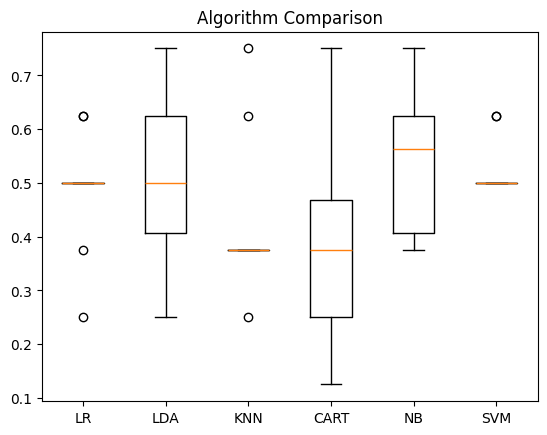

In [34]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

# Compare Algorithms
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()